In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score

In [22]:
train_df = pd.read_csv("Data/train.csv").drop(columns=['ID'])
test_df = pd.read_csv("Data/test.csv").drop(columns=['ID'])

In [23]:
def drop_high_missing_columns(df, threshold=0.5):
    missing_ratio = df.isnull().sum() / len(df)
    columns_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
    df_cleaned = df.drop(columns=columns_to_drop)
    return df_cleaned, columns_to_drop

In [24]:
# 결측치 비율 50% 넘는 열 삭제
train_cleaned, dropped_columns = drop_high_missing_columns(train_df, threshold=0.03)
print(dropped_columns)
test_cleaned, dropped_columns = drop_high_missing_columns(test_df, threshold=0.03)
print(dropped_columns)

['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일', '난자 해동 경과일', '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일']
['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일', '난자 해동 경과일', '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일']


In [25]:
train_cleaned = train_cleaned.dropna()
test_cleaned = test_cleaned.dropna()

d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\s

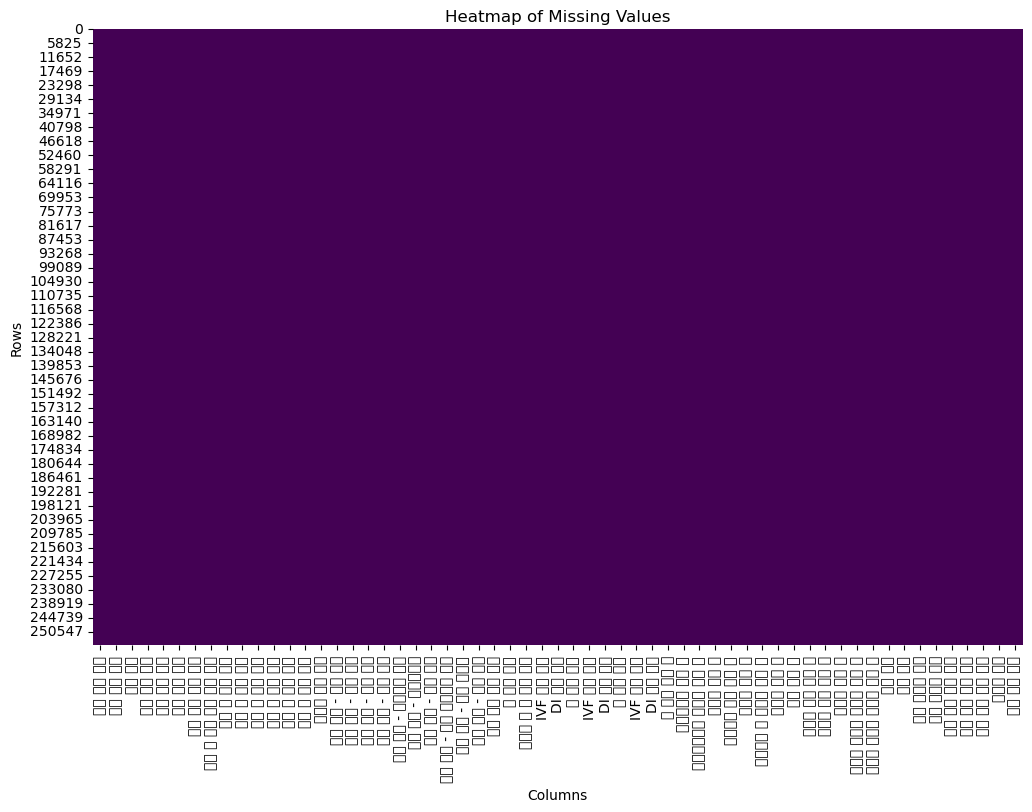

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [26]:
X = train_cleaned.drop(["임신 성공 여부"], axis=1)
y = train_cleaned["임신 성공 여부"]

In [27]:
categorical_cols = X.select_dtypes(include=['object']).columns
encoder_dict = {}
for col in categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[col] = encoder.fit_transform(X[[col]])
    test_cleaned[col] = encoder.transform(test_cleaned[[col]])
    encoder_dict[col] = encoder

In [28]:
X_c = X.loc[:, (X != 0).any(axis=0)]
X_c.columns

Index(['시술 시기 코드', '시술 당시 나이', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형',
       '단일 배아 이식 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인',
       '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인',
       '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 자궁경부 문제',
       '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인',
       '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '배아 생성 주요 이유', '총 시술 횟수',
       '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수',
       'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '총 생성 배아 수',
       '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수',
       '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수',
       '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처',
       '난자 기증자 나이', '정자 기증자 나이', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부',
       '대리모 여부'],
      dtype='object')

In [38]:
corr_matrix = X_c.corr(method='pearson')
threshold = 0.7
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(abs(upper_triangle[column]) > threshold)]
X_f = X_c.drop(columns=to_drop)
X_f.columns

Index(['시술 시기 코드', '시술 당시 나이', '특정 시술 유형', '배란 자극 여부', '단일 배아 이식 여부',
       '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 부 불임 원인',
       '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애',
       '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도',
       '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '배아 생성 주요 이유',
       '총 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'DI 임신 횟수', '총 생성 배아 수', '미세주입된 난자 수',
       '이식된 배아 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수',
       '저장된 신선 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '기증 배아 사용 여부', '대리모 여부'],
      dtype='object')

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X_f, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
y_val_proba = model.predict_proba(X_val)[:,1]
y_val_pred = (y_val_proba > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("AUC PR:", average_precision_score(y_val, y_val_proba))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))

Accuracy: 0.7062105094777253
              precision    recall  f1-score   support

           0       0.77      0.87      0.81     37069
           1       0.39      0.25      0.30     12943

    accuracy                           0.71     50012
   macro avg       0.58      0.56      0.56     50012
weighted avg       0.67      0.71      0.68     50012

AUC PR: 0.3668966220685074
ROC AUC: 0.6769432528904716


In [ ]:

numerical_cols = train_cleaned.select_dtypes(include=['int64','float64']).columns